---
title: 'Polynomial Modeling and Regression'
---

In [1]:
import numpy as np
from scipy.fft import fft, ifft, fftshift
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt
import pickle
from copy import copy
%matplotlib inline

In [2]:
def xp_mat_maker(xvals, p):
    xp = np.ones((xvals.size, p+1))
    for jj in range(p):
        xp[:, jj+1] = xvals * xp[:, jj]
    return xp

In [3]:
def least_squares_solve(mat, yvals):
    u, s, vt = np.linalg.svd(mat, full_matrices=False)
    alpha = (vt.T @ np.diag(1./s) @ u.T) @ yvals.reshape(-1, 1)
    error = np.linalg.norm(mat @ alpha - yvals.reshape(-1, 1))**2./(2.*yvals.size)
    return alpha, error 

In [4]:
def least_squares_solve_w_cond(mat, yvals, lam_val):
    u, s, vt = np.linalg.svd(mat, full_matrices=False)
    regxmat = (vt.T @ np.diag(s/(s**2.+lam_val)) @ u.T)
    alpha = regxmat @ yvals.reshape(-1, 1)
    error = np.linalg.norm(mat @ alpha - yvals.reshape(-1, 1))**2./(2.*yvals.size)
    return alpha, error, regxmat

## Regression Modeling

So, suppose I give you data in graph form so that your data set is given by $\left\{(x_{j},y_{j})\right\}_{j=1}^{N_{d}}$.  Further, we suppose that $y_{j}$ and $x_{j}$ are related through some unknown funciton $f(x)$ but we also have noise so that 
$$
y_{j} = f(x_{j}) + \epsilon_{j}, ~ \epsilon_{j} \sim \mathcal{N}(0,\sigma).
$$

Here, the notation $\epsilon_{j} \sim \mathcal{N}(0,\sigma)$ means that $\epsilon_{j}$ is a Gaussian (normal) random variable sampled from a zero mean, $\sigma^{2}$ variance distribution.  We typically further assume the random variables $\epsilon_{j}$ are independent.  If we also suppose that we have no idea what $f(x)$ is, then we have to model it.  

### Linear Least Squares 

The most straightforward way to do so is via a linear relationship, i.e., $f(x) \approx mx + b$, and thus we want to find the optimal $(m,b)$ pair to fit our data.  Writing things in terms of matrices and vectors, if we introduce the matrix ${\bf X}$ where 
$$
{\bf X} = \begin{pmatrix}1 & x_{1}\\ \vdots & \vdots \\ 1 & x_{N_{d}}\end{pmatrix},
$$
then what we are really trying to say is that $\boldsymbol{\epsilon} \approx {\bf y} - {\bf X}\begin{pmatrix}b \\ m \end{pmatrix}$ is $N_{d}$ independent and identically distributed Gaussian random variables.  Thus, from independence, we can write the matrix ${\bf C} = \sigma^{2}{\bf I}$ and thus 

\begin{align*}
p(\boldsymbol{\epsilon}) = & \frac{1}{(2\pi\sigma^{2})^{n/2}} ~\text{exp}\left( -\frac{1}{2\sigma^{2}}\left<{\bf y} - {\bf X}\begin{pmatrix}b \\ m \end{pmatrix},{\bf y} - {\bf X}\begin{pmatrix}b \\ m \end{pmatrix}\right>\right)\\
= & \frac{1}{(2\pi\sigma^{2})^{n/2}} ~\text{exp} \left( -\frac{1}{2\sigma^{2}}\left|\left|{\bf y} - {\bf X}\begin{pmatrix}b \\ m \end{pmatrix}\right|\right|^{2}_{2} \right)
\end{align*}

We thus see that if we use parameters $(b_{\ast},m_{\ast})$ where

$$
(b_{\ast},m_{\ast}) = \text{arg min}_{(b,m)} \left|\left|{\bf y} - {\bf X}\begin{pmatrix}b \\ m \end{pmatrix}\right|\right|^{2}_{2},
$$

then we have maximized the probability distribution $p(\boldsymbol{\epsilon})$.  In other words, we choose model parameters so as to maximize the *likelihood* of our data being related via a linear model relative to our assumption of independent, identically distributed Gaussian noise.  

### Higher-Order Modeling 

Now, if we don't know $f(x)$, we have to model, and so, motivated by Taylor series, it is very natural to use a polynomial, say $\pi_{d}(x)$ to approximate $f(x)$.  Thus, fixing the degree $d$ of $\pi_{d}(x)$, then we can write it as 
$$
\pi_{d}(x) = \sum_{l=0}^{d}\alpha_{l}x^{l},
$$
and so the question is now how to determine the coefficients $\alpha_{l}$ from data.  Assembling our data in a matrix/vector format, we see that our modeling question turns into finding those values $\boldsymbol{\alpha}_{\ast}\in\mathbb{R}^{d+1}$ such that
$$
\boldsymbol{\alpha}_{\ast} = \text{arg min}_{\boldsymbol{\alpha}}\left|\left|{\bf y} - {\bf X}\boldsymbol{\alpha}\right|\right|^{2}_{2}
$$
where the $N_{d}\times (d+1)$ matrix ${\bf X}$ is given by 
$$
{\bf X} = \begin{pmatrix}1 & x_{1} & \cdots & x_{1}^{d}\\ \vdots & \vdots & \ddots & \vdots \\ 1 & x_{N_{d}} & \cdots & x_{N_{d}}^{d}\end{pmatrix}.
$$

To solve our optimization problem, we note that 

\begin{align*} 
\left|\left| {\bf y} - {\bf X} \boldsymbol{\alpha} \right|\right|^{2}_{2} = & \left<{\bf y} - {\bf X}\boldsymbol{\alpha}, {\bf y} - {\bf X}\boldsymbol{\alpha} \right> \\
= & \left|\left|{\bf y}\right|\right|_{2}^{2} - 2\left<{\bf y},{\bf X}\boldsymbol{\alpha}\right> + \left<{\bf X}\boldsymbol{\alpha},{\bf X}\boldsymbol{\alpha}\right>\\
= & \left|\left|{\bf y}\right|\right|_{2}^{2} - 2\left<{\bf X}^{T}{\bf y},\boldsymbol{\alpha}\right> + \left<{\bf X}^{T}{\bf X}\boldsymbol{\alpha},\boldsymbol{\alpha}\right>.
\end{align*}

Supposing that we have more data than we have degree, i.e. $N_{d} > d$, so that ${\bf X}$ is square or overdetermined, then if we also suppose that ${\bf X}$ is full rank (what ensures this?), we can write
$$
{\bf X} = {\bf U}\boldsymbol{\Sigma}{\bf V}^{T}.  
$$
Defining the transformed parameter variable $\boldsymbol{\tilde{\alpha}} = {\bf V}^{T}\boldsymbol{\alpha}$, we see that the function that we want to optimize can be rewritten in the diagonlized form (as it were)
$$
\left|\left| {\bf y} - {\bf X} \boldsymbol{\alpha} \right|\right|^{2}_{2} = \left|\left|{\bf y}\right|\right|_{2}^{2} - 2\left<{\bf \tilde{y}},\boldsymbol{\tilde{\alpha}}\right> + \left<\boldsymbol{\Sigma}^{2}\boldsymbol{\tilde{\alpha}},\boldsymbol{\tilde{\alpha}}\right>, ~ {\bf \tilde{y}} = \boldsymbol{\Sigma}{\bf U}^{T}{\bf y}.
$$

*Problem*: Show that 

\begin{equation*}
\frac{\partial}{\partial \tilde{\alpha}_{k}} \left(- 2\left<{\bf \tilde{y}},\boldsymbol{\tilde{\alpha}}\right> + \left<\boldsymbol{\Sigma}^{2}\boldsymbol{\tilde{\alpha}},\boldsymbol{\tilde{\alpha}}\right>\right) = -2\tilde{y}_{k} + 2\sigma_{k}^{2}\tilde{\alpha}_{k}.
\end{equation*}

*Problem*: Show that 

\begin{align*}
\boldsymbol{\tilde{\alpha}}_{\ast} = & \boldsymbol{\Sigma}^{-2}{\bf \tilde{y}}\\
= & \boldsymbol{\Sigma}^{-1}{\bf U}^{T}{\bf y}.
\end{align*}

*Problem*: Finally, show that 

\begin{align*}
\boldsymbol{\alpha}_{\ast} = & {\bf V}\boldsymbol{\Sigma}^{-1}{\bf U}^{T}{\bf y}\\
= & \left({\bf X}^{T}{\bf X}\right)^{-1}{\bf X}^{T}{\bf y}
\end{align*}

The role of the matrix $\left({\bf X}^{T}{\bf X}\right)^{-1}{\bf X}^{T}$ is so ubiquitous and useful throughout data science (and a fair bit of applied linear algebra), that it gets the distinguished name of the *Moore-Penrose Pseudoinverse* of ${\bf X}$, denoted as ${\bf X}^{-P}$, i.e.

\begin{equation*}
{\bf X}^{-P} = \left({\bf X}^{T}{\bf X}\right)^{-1}{\bf X}^{T}.
\end{equation*}

This is well defined for overdetermined matrices of full rank, i.e. ${\bf X}$ is $m\times n$ with $m\geq n = \text{rank}({\bf X})$.

*Problem*: Show that for $n\times n$ matrix ${\bf X}$, if ${\bf X}^{-1}$ exists then ${\bf X}^{-P}={\bf X}^{-1}$.  

So, let's see what happens if we try to model some relatively oscillatory data.  We let our data $\left\{(x_{j},y_{j})\right\}_{j=1}^{N_{D}}$ be given by 

$$
y_{j} = x_{j} - \frac{x_{j}^{3}}{3!} + \frac{x_{j}^{5}}{5!} - \frac{x_{j}^{7}}{7!} + \frac{x_{j}^{9}}{9!} + \epsilon_{j}
$$

for $1\leq x \leq 5$ and $\epsilon_{j} \sim \mathcal{N}(0,\sigma^{2})$ with $\sigma=.1$.  



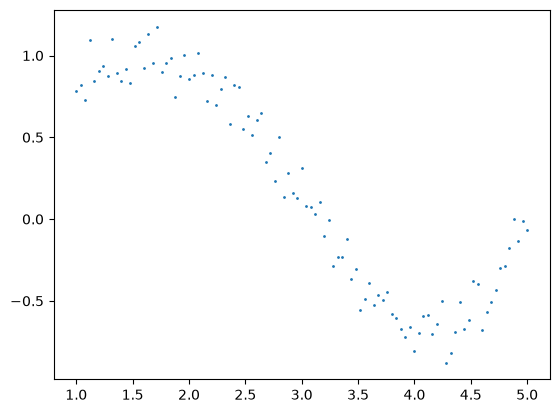

In [5]:
# equispaced data 

xvals = np.linspace(1., 5., int(1e2)+1)
sig = .1
ftrue = lambda x: x - x**3./6. + x**5./120. - x**7./(42. * 120) + x**9./(72*42*120)

yvals = ftrue(xvals) + sig*np.random.randn(xvals.size)

plt.scatter(xvals, yvals, s=1.)

So while we know we are working with the five term MacLaurin series approximation of $\sin(x)$ we look at building regression models with $p=3, 4, 5, 6, 7$.  While literal 2-norm fit quality is certainly a consideration, we also have to think about the degree to which we can *generalize* our model, i.e., how well can it interpolate between existing data points and how well do we think that it can predict new results beyond the range of our data.  One way to assess the quality of generalizability is by way of the condition number of ${\bf X}$.  Denoting this as $c({\bf X})$ we define it as 

$$
c({\bf X}) = \frac{\sigma_{1}}{\sigma_{p+1}}.
$$

Typically, the larger $c({\bf X})$ is, the less generalizable the model will be.  Let's try to see how this shows up in practice.  This comes from the fact that large conditioning leads to a wide spread in the values of $\boldsymbol{\alpha}_{\ast}$ since 

$$
\boldsymbol{\alpha}_{\ast} = {\bf V}\boldsymbol{\Sigma}^{1}{\bf U}^{T}{\bf y},
$$

and since ${\bf V}$ and ${\bf U}$ cannot change size, it is the spread in singular values which creates strong disparities in the values in $\boldsymbol{\alpha}_{\ast}$.  In turn, when we try to use model $f_{m}(x)$ where 

$$
f_{m}(x) = \sum_{l=0}^{p}\alpha_{\ast,l} x^{l},
$$

we expect that if $c({\bf X})\gg 1$, then certain polynomial terms will dominate for even moderate values of $x$ thereby destroying the quality of the model outside of the range of the data.  Let's see this in action.  

In [6]:
pvals = [3, 4, 5, 6, 7]
models = [None]*len(pvals)
alphas = [None]*len(pvals)
errors = [None]*len(pvals)

for cnt, pval in enumerate(pvals):
    models[cnt] = xp_mat_maker(xvals, pval)
    alphas[cnt], errors[cnt] = least_squares_solve(models[cnt], yvals)



Model residual for p = 3: 0.005792256092595618
Condition number of model matrix is: 1506.6974205703455

Model residual for p = 4: 0.005173651263338562
Condition number of model matrix is: 22617.865032988244

Model residual for p = 5: 0.005053192198493925
Condition number of model matrix is: 356134.4401318731

Model residual for p = 6: 0.005031569739669231
Condition number of model matrix is: 5779472.683138319

Model residual for p = 7: 0.005029743265641868
Condition number of model matrix is: 95795821.36563875



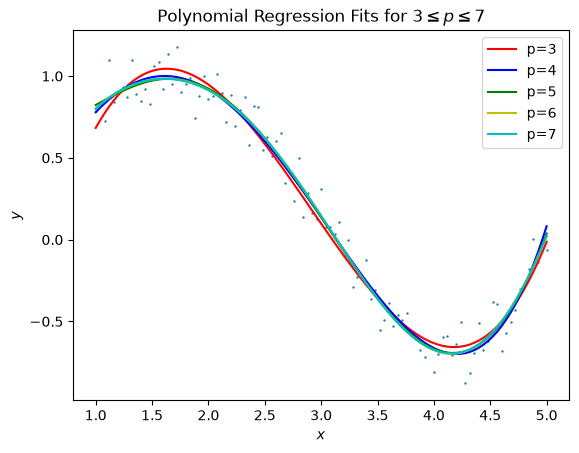

In [7]:
plt.scatter(xvals, yvals, s=.5)
colors = ['r', 'b', 'g', 'y', 'c']
for cnt, pval in enumerate(pvals):
    myfit = models[cnt] @ alphas[cnt].reshape(-1, 1)
    plt.plot(xvals, myfit, c=colors[cnt], label="p="+str(pval))
    print(f"Model residual for p = {pval}: {errors[cnt]}")
    print(f"Condition number of model matrix is: {np.linalg.cond(models[cnt])}\n")
plt.legend()
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title(r"Polynomial Regression Fits for $3\leq p \leq 7$");

So all of the fits look fine, but the condition numbers grow dramatically as we increase the polynomial order $p$ of our models.  This variablity in conditioning leads to extremes in the values in $\boldsymbol{\alpha}_{\ast}$ as we see in the following plot.  

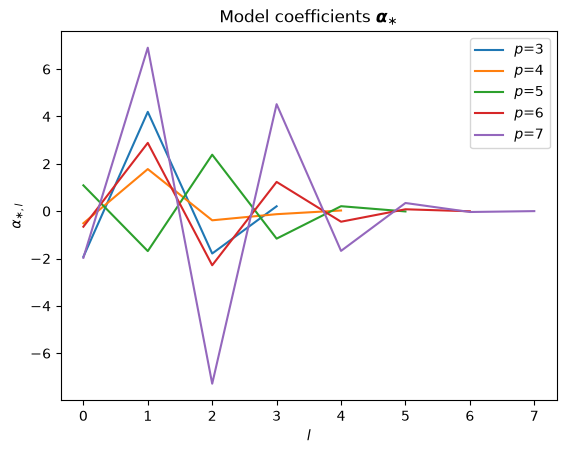

In [11]:
for jj in range(len(pvals)):
    pval = r"$p$=" + str(jj + 3)
    plt.plot(alphas[jj], label=pval)
plt.legend()
plt.xlabel(r"$l$")
plt.ylabel(r"$\alpha_{\ast,l}$")
plt.title(r"Model coefficients $\boldsymbol{\alpha}_{\ast}$");


The consequence of this wider spread in mode parameter values is seen when we try to go outside the domain of the data by plotting $f_{m}(x)$ for $0\leq x \leq 5$.  

Text(0.5, 1.0, '$f_{m}(x)$ beyond range of data')

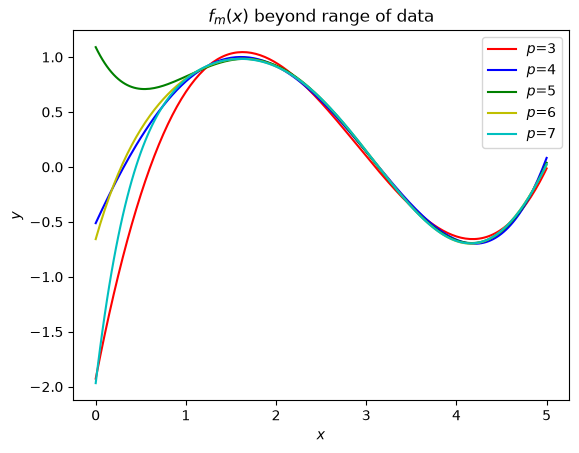

In [13]:
xfine = np.linspace(0., 5., int(2e2)+1)

for cnt, pval in enumerate(pvals):
    fine_model = xp_mat_maker(xfine, pval)
    ypred = fine_model @ alphas[cnt].reshape(-1,1)
    plt.plot(xfine, ypred, c=colors[cnt], label=r"$p$="+str(pval))
plt.legend()
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title(r"$f_{m}(x)$ beyond range of data")


As can be seen, all of the higher-order models fail to make meaningful predictions on $x\in[0,1]$ and instead exhibit rapidly increasing growth in $f_{m}(x)$.  

## Regularization

One way to deal with the impact that increasing conditioning has in our modeling is to introduce a *regularization* term into our modeling.  This is typically done by changing the optimizaiton problem to 

$$
\boldsymbol{\alpha}_{\ast} = \text{arg min}_{\boldsymbol{\alpha}} \left|\left|{\bf y} - {\bf X}\boldsymbol{\alpha}\right|\right|_{2}^{2} + \lambda \left|\left|\boldsymbol{\alpha}\right|\right|_{2}^{2}, ~ \lambda > 0.  
$$

The constant $\lambda>0$ is called a *regularization parameter*.  To see the impact of this decision, again using the SVD of ${\bf X}={\bf U}\boldsymbol{\Sigma}{\bf V}^{T}$, we see that 

\begin{align*}
\left|\left|{\bf y} - {\bf X}\boldsymbol{\alpha}\right|\right|_{2}^{2} + \lambda \left|\left|\boldsymbol{\alpha}\right|\right|_{2}^{2} = & \left|\left|{\bf y}\right|\right|_{2}^{2} - 2\left<{\bf y},{\bf X}\boldsymbol{\alpha}\right> + \left<{\bf X}\boldsymbol{\alpha},{\bf X}\boldsymbol{\alpha}\right> + \lambda \left<\boldsymbol{\alpha},\boldsymbol{\alpha}\right>\\
= & \left|\left|{\bf y}\right|\right|_{2}^{2} - 2\left<\tilde{{\bf y}},\boldsymbol{\Sigma}\tilde{\boldsymbol{\alpha}}\right> + \left<\boldsymbol{\Sigma}^{2}\tilde{\boldsymbol{\alpha}},\tilde{\boldsymbol{\alpha}}\right> + \lambda \left<\tilde{\boldsymbol{\alpha}},\tilde{\boldsymbol{\alpha}}\right>
\end{align*}

where again $\tilde{{\bf y}} = {\bf U}^{T}{\bf y}$ and $\tilde{\boldsymbol{\alpha}} = {\bf V}^{T}\boldsymbol{\alpha}$.  Having diagonalized as it were, now when we differentiate with respect to $\tilde{\alpha}_{k}$ and look for critical poitns, we now find

$$
\tilde{\alpha}_{\ast,k} = \frac{\sigma_{k}}{\sigma_{k}^{2}+\lambda}\tilde{y}_{k},
$$

and thus 

$$
\boldsymbol{\alpha}_{\ast} = {\bf V}\boldsymbol{\Sigma}\left(\boldsymbol{\Sigma}^{2}+\lambda{\bf I}\right)^{-1}{\bf U}^{T}{\bf y}.
$$

We now have an equivalent model matrix $\tilde{{\bf X}} = {\bf U}\boldsymbol{\Sigma}^{-1}\left(\boldsymbol{\Sigma}^{2}+\lambda{\bf I}\right){\bf V}^{T}$, so that for $\lambda >0$

$$
c(\tilde{{\bf X}}) = \frac{\sigma_{1}+\lambda/\sigma_{1}}{\sigma_{p+1}+\lambda/\sigma_{p+1}}.
$$

We then find that 

$$
\frac{d c(\tilde{{\bf X}})}{d\lambda} = \frac{\sigma_{p+1}^{2}-\sigma_{1}^{2}}{\sigma_{1}\sigma_{p+1}(\sigma_{p+1}+\lambda/\sigma_{p+1})^{2}} < 0,
$$

and

$$
\lim_{\lambda \rightarrow \infty} c(\tilde{{\bf X}}) = \frac{\sigma_{p+1}}{\sigma_{1}}.  
$$

Thus as we increasing $\lambda$, we will always be decreasing the condition number of the equivalent model matrix, but at the cost of accuracy with regards to the fit.  Thus, regularization is always a bit of art as much as science.  Let's see what happens though if we choose a modest value of $\lambda$ and proceed.  

In [14]:
pvals = [3, 4, 5, 6, 7]
models = [None]*len(pvals)
alphas = [None]*len(pvals)
errors = [None]*len(pvals)
regmats = [None]*len(pvals)
lam_val = .1

for cnt, pval in enumerate(pvals):
    models[cnt] = xp_mat_maker(xvals, pval)
    alphas[cnt], errors[cnt], regmats[cnt] = least_squares_solve_w_cond(models[cnt], yvals, lam_val)

Model residual for p = 3: 0.008551189814410597
Condition number of model matrix is: 861.78572547919

Model residual for p = 4: 0.0053158232448989465
Condition number of model matrix is: 2346.2431394258006

Model residual for p = 5: 0.0051602641221828605
Condition number of model matrix is: 16291.392844421154

Model residual for p = 6: 0.005038931514443055
Condition number of model matrix is: 61485.16019167377

Model residual for p = 7: 0.005038932535242829
Condition number of model matrix is: 340565.3236838983



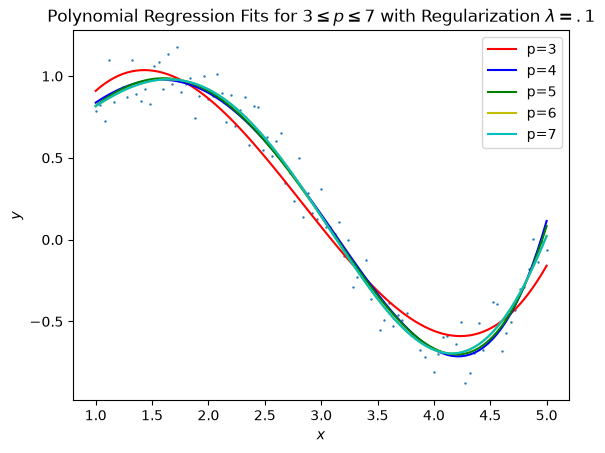

In [15]:
plt.scatter(xvals, yvals, s=.5)
colors = ['r', 'b', 'g', 'y', 'c']
for cnt, pval in enumerate(pvals):
    myfit = models[cnt] @ alphas[cnt].reshape(-1, 1)
    plt.plot(xvals, myfit, c=colors[cnt], label="p="+str(pval))
    print(f"Model residual for p = {pval}: {errors[cnt]}")
    print(f"Condition number of model matrix is: {np.linalg.cond(regmats[cnt])}\n")
plt.legend()
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title(r"Polynomial Regression Fits for $3\leq p \leq 7$ with Regularization $\lambda=.1$");

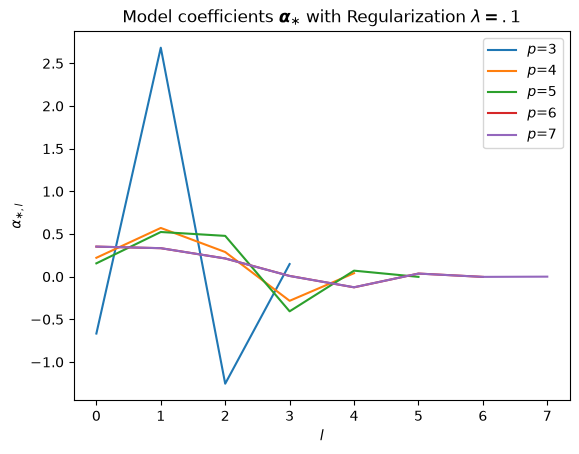

In [16]:
for jj in range(len(pvals)):
    pval = r"$p$=" + str(jj + 3)
    plt.plot(alphas[jj], label=pval)
plt.legend()
plt.xlabel(r"$l$")
plt.ylabel(r"$\alpha_{\ast,l}$")
plt.title(r"Model coefficients $\boldsymbol{\alpha}_{\ast}$ with Regularization $\lambda=.1$");

Text(0.5, 1.0, '$f_{m}(x)$ beyond range of data with Regularization $\\lambda=.1$')

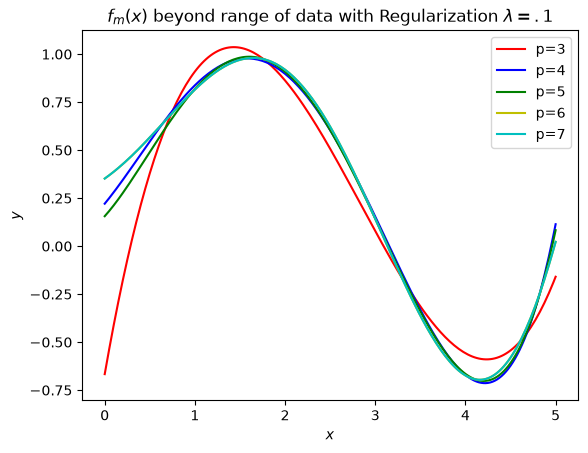

In [18]:
xfine = np.linspace(0., 5., int(2e2)+1)

for cnt, pval in enumerate(pvals):
    fine_model = xp_mat_maker(xfine, pval)
    ypred = fine_model @ alphas[cnt].reshape(-1,1)
    plt.plot(xfine, ypred, c=colors[cnt], label="p="+str(pval))
plt.legend()
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title(r"$f_{m}(x)$ beyond range of data with Regularization $\lambda=.1$")



So as we see, introducion regularization largely cures all of the ills we saw in the prior section, and ultimately we are able to use higher-order models that behave well outside the range of the data.  